# Data Understanding & Preprocessing

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('../data/spiff_data-2.csv')

# Basic inspection
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5456 entries, 0 to 5455
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    5456 non-null   int64  
 1   day           5456 non-null   int64  
 2   gurkor        5206 non-null   float64
 3   guitars       5206 non-null   float64
 4   slingshots    5206 non-null   float64
 5   stocks        5206 non-null   float64
 6   sugar         5206 non-null   float64
 7   water         5206 non-null   float64
 8   tranquillity  5206 non-null   float64
dtypes: float64(7), int64(2)
memory usage: 383.8 KB


,Unnamed: 0,day,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
count,5456.000000,5456.000000,5206.000000,5206.000000,5206.000000,5206.000000,5206.000000,5206.000000,5206.000000
mean,2727.500000,2728.500000,9.886550,6.713898,4.519504,7.309093,3.621403,6.749451,12.502258
std,1575.155865,1575.155865,30.785709,30.850516,30.883866,30.856220,30.904930,30.825744,30.774131
min,0.000000,1.000000,5.942896,2.629048,2.001362,4.012346,1.370262,3.739412,6.614749
25%,1363.750000,1364.750000,6.948963,4.258847,2.808930,4.917271,1.999489,4.996764,9.194215
50%,2727.500000,2728.500000,8.907936,5.912364,3.384898,5.521318,2.606234,5.775716,10.591227
75%,4091.250000,4092.250000,10.191398,7.058370,4.294821,6.977501,3.281805,6.492295,13.382072
max,5455.000000,5456.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000


The value 1000 appears five times in each series and is inconsistent with the rest of the data distribution. It is therefore interpreted as a placeholder for missing values and replaced with NaN.

In [ ]:
(df == 1000).sum()
df = df.replace(1000, np.nan)

Unnamed: 0      1
day             1
gurkor          5
guitars         5
slingshots      5
stocks          5
sugar           5
water           5
tranquillity    5
dtype: int64

The column “Unnamed: 0” is an artifact of CSV export and removed. The “day” column is used as the time index.

In [8]:
df = df.drop(columns=["Unnamed: 0"])
df = df.set_index("day")

In [9]:
# Check missing structure
df.isna().sum()

gurkor          255
guitars         255
slingshots      255
stocks          255
sugar           255
water           255
tranquillity    255
dtype: int64

Reasonable. 200 missing values at the end + 50 missing within + 5 removed because of inconsisitency.

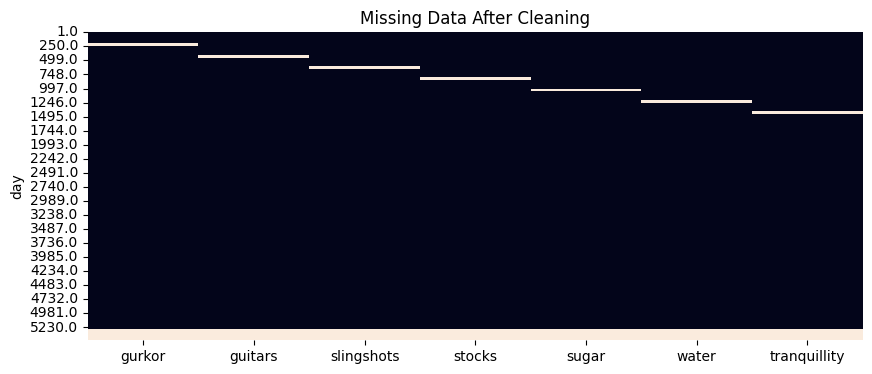

In [11]:
import seaborn as sns
plt.figure(figsize=(10,4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Data After Cleaning")
plt.show()

Sugar looks a little bit thinner than others.

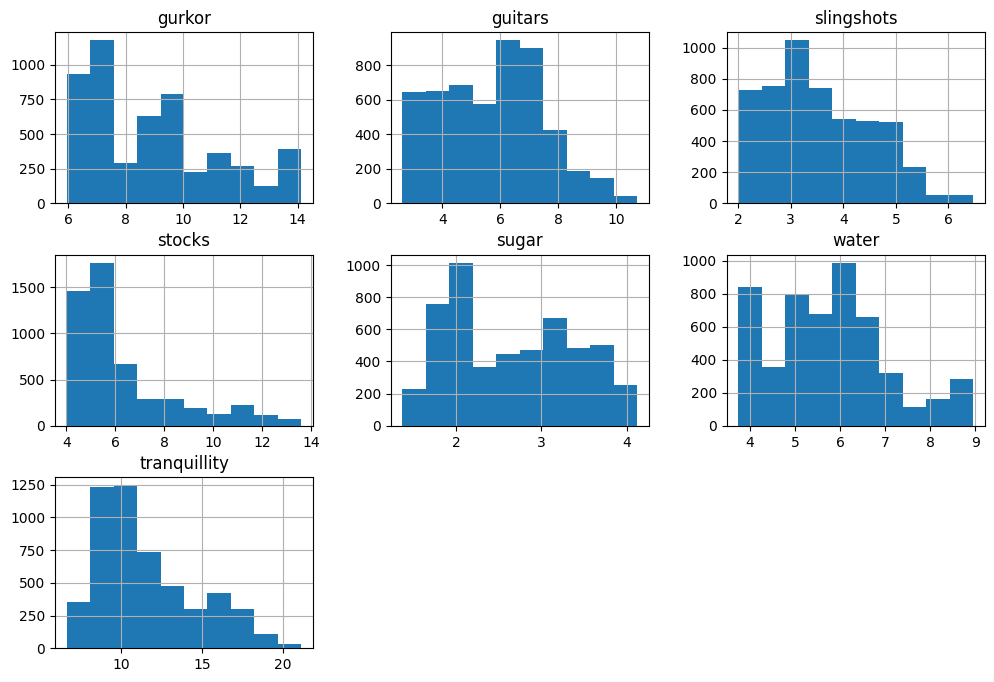

In [ ]:
df.hist(figsize=(12,8))
plt.show()

In [13]:
df.duplicated().sum()

np.int64(204)

<Axes: xlabel='day'>

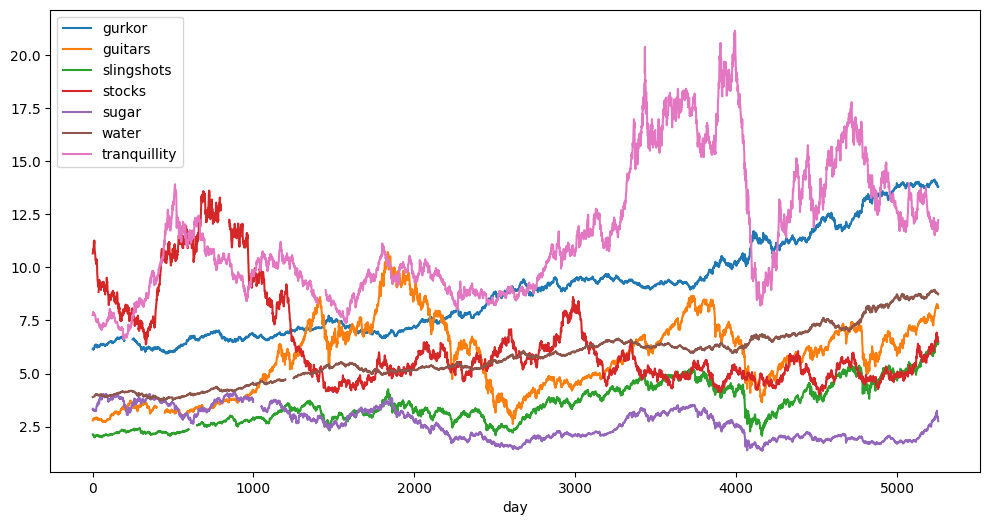

In [15]:
df_returns = np.log(df / df.shift(1))
df.plot(figsize=(12,6))

For the preprocessing step we have (i) replaced inconsistent extreme values with NaN, (ii) ensured 200 missing at the end, and (ii) ensured 50 missing internally. We create a new file with clean data.

In [21]:
df.to_csv('../data/processed_data.csv', index=False, sep=',', encoding='utf-8', na_rep='NaN')